# EDA: Predicting Movie/Show Genre from Soundtrack Audio Features

## Background & issue statement

Can we predict a movie or TV show's genre (e.g. Drama, Action, Comedy) using only the acoustic audio features of songs on its soundtrack? Studios, streaming platforms, and recommendation engines rely on genre labels, but labeling is manual, subjective, and inconsistent across catalogs. If acoustic features of soundtrack music carry a detectable genre signal, we could automate or augment genre tagging at scale.

Our dataset joins four sources via exact ID matching:
- **MusicBrainz** release-group & release dumps: soundtrack albums linked to movies via IMDB ID, with recording-level track metadata
- **AcousticBrainz** feature CSVs: acoustic descriptors for each recording, joined on a MusicBrainz Recording MBID
- **TMDB** Kaggle dataset: movie genre labels, joined on IMDB ID

The target variable is `primary_movie_genre` -- the first genre listed in TMDB's comma-separated genre field for each movie.

## Variables

| Variable | Role | Type | Description |
|----------|------|------|-------------|
| `primary_movie_genre` | **Target** | Categorical | First TMDB genre (e.g. Drama, Action) |
| `bpm` | Feature | Continuous | Estimated beats per minute |
| `danceability` | Feature | Continuous | How suitable the track is for dancing |
| `onset_rate` | Feature | Continuous | Rate of note/beat onsets per second |
| `average_loudness` | Feature | Continuous | Perceived loudness (0-1 scale) |
| `dynamic_complexity` | Feature | Continuous | Loudness variation over time |
| `mfcc_zero_mean` | Feature | Continuous | Zeroth MFCC coefficient mean (spectral energy) |
| `tuning_frequency` | Feature | Continuous | Estimated tuning reference (Hz) |
| `tuning_equal_tempered_deviation` | Feature | Continuous | Deviation from standard temperament |
| `bpm_histogram_*` (4 cols) | Feature | Continuous | BPM of dominant/secondary rhythmic peaks |
| `key_A` through `key_G#` | Feature | Binary | One-hot encoded musical key (12 cols) |
| `scale_minor` | Feature | Binary | 1 = minor key, 0 = major key |


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/movie_genre_audio_features_cleaned.csv") 

## Data types, null audit, and summary statistics


In [3]:
info_df = pd.DataFrame({
    "data type": df.dtypes,
    "null count": df.isnull().sum(),
    "unique values": df.nunique(),
})
print(info_df.to_string())


                                     data type  null count  unique values
recording_mbid                             str           0         116192
track_title                                str           0          97410
artist                                     str           0          16464
imdb_id                                    str           0           6765
rg_id                                      str           0           7195
rg_title                                   str           0           7079
primary_movie_genre                        str           0             19
movie_genres                               str           0           1577
tmdb_id                                  int64           0           6765
tmdb_title                                 str           0           6635
average_loudness                       float64           0         115597
bpm                                    float64           0         108757
bpm_histogram_first_peak_bpm_mean     

In [4]:
# Continuous audio features
CONTINUOUS_FEATURES = [
    "bpm", "danceability", "onset_rate",
    "average_loudness", "dynamic_complexity", "mfcc_zero_mean",
    "tuning_frequency", "tuning_equal_tempered_deviation",
    "bpm_histogram_first_peak_bpm_mean", "bpm_histogram_first_peak_bpm_median",
    "bpm_histogram_second_peak_bpm_mean", "bpm_histogram_second_peak_bpm_median",
]

# Binary one-hot features
ONEHOT_FEATURES = [c for c in df.columns if c.startswith("key_") or c == "scale_minor"]

print(f"Continuous features ({len(CONTINUOUS_FEATURES)}): {CONTINUOUS_FEATURES}")
print(f"\nOne-hot features ({len(ONEHOT_FEATURES)}): {ONEHOT_FEATURES}")
print(f"\nTotal model features: {len(CONTINUOUS_FEATURES) + len(ONEHOT_FEATURES)}")


Continuous features (12): ['bpm', 'danceability', 'onset_rate', 'average_loudness', 'dynamic_complexity', 'mfcc_zero_mean', 'tuning_frequency', 'tuning_equal_tempered_deviation', 'bpm_histogram_first_peak_bpm_mean', 'bpm_histogram_first_peak_bpm_median', 'bpm_histogram_second_peak_bpm_mean', 'bpm_histogram_second_peak_bpm_median']

One-hot features (13): ['key_A', 'key_A#', 'key_B', 'key_C', 'key_C#', 'key_D', 'key_D#', 'key_E', 'key_F', 'key_F#', 'key_G', 'key_G#', 'scale_minor']

Total model features: 25


In [5]:
# Summary statistics for continuous features
df[CONTINUOUS_FEATURES].describe().round(3).T


,count,mean,std,min,25%,50%,75%,max
bpm,116192.0,125.397,24.586,0.000,107.247,123.335,143.152,224.694
danceability,116192.0,0.983,0.190,0.000,0.848,0.936,1.077,3.577
onset_rate,116192.0,2.285,1.422,0.006,1.058,2.105,3.363,12.305
average_loudness,116192.0,0.428,0.347,0.000,0.074,0.379,0.786,0.991
dynamic_complexity,116192.0,6.258,2.779,0.000,4.275,5.771,7.700,67.388
mfcc_zero_mean,116192.0,-757.455,71.241,-1107.168,-807.981,-761.186,-704.254,-528.544
tuning_frequency,116192.0,439.240,4.450,431.194,434.193,440.000,441.783,456.570
tuning_equal_tempered_deviation,116192.0,0.112,0.096,0.000,0.026,0.080,0.198,0.491
bpm_histogram_first_peak_bpm_mean,116192.0,125.954,24.344,0.000,108.000,123.000,144.000,225.000
bpm_histogram_first_peak_bpm_median,116192.0,125.954,24.344,0.000,108.000,123.000,144.000,225.000


## Visual 1: Target variable distribution

First, we look at the distribution of `primary_movie_genre` before modeling.


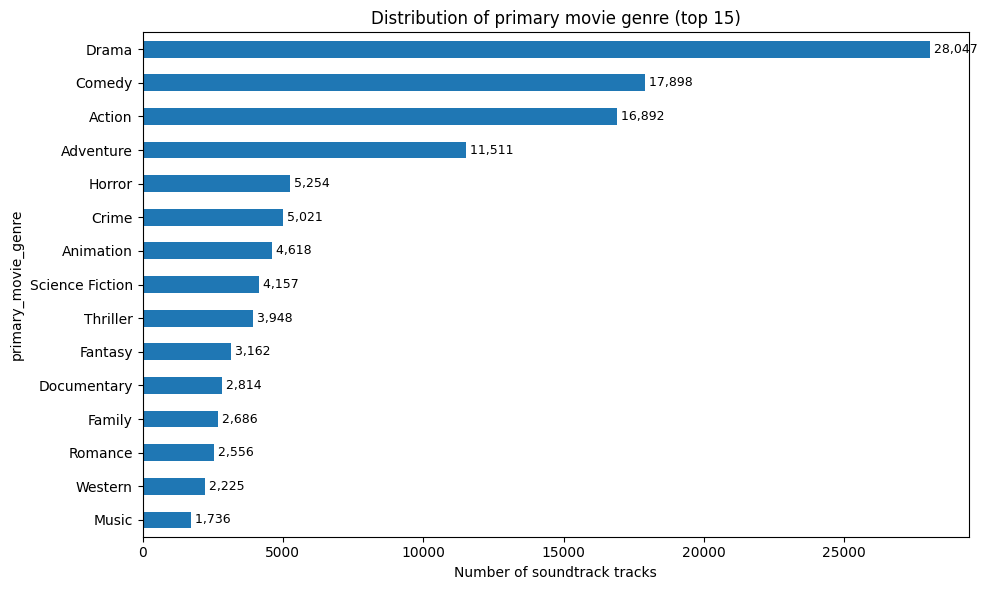

Total genres: 19
Top genre share: 24.1%


In [9]:
# Count how many tracks belong to each genre, sorted highest to lowest
genre_counts = df["primary_movie_genre"].value_counts()

# Keep only the top 15 genres for the chart
top_genres = genre_counts.head(15)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
top_genres.plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_xlabel("Number of soundtrack tracks")
ax.set_title("Distribution of primary movie genre (top 15)")

for i, value in enumerate(top_genres):
    ax.text(value, i, f" {value:,}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("01_genre_distribution.png", bbox_inches="tight")
plt.show()

# Summary stats
print(f"Total genres: {df['primary_movie_genre'].nunique()}")
print(f"Top genre share: {genre_counts.iloc[0] / len(df) * 100:.1f}%")

We can see that the genre distribution is skewed, with the Drama genre dominating (28k tracks) and a long tail of more rare genres (like Music, with 1.7k tracks). 

This confirms we'll need to address class imbalance during preprocessing 
(SMOTE, class weights, or merging rare genres into an "Other" bucket).

## Visual 2: Feature distributions

Here, we understand the shape, spread, and skew of each continuous feature.


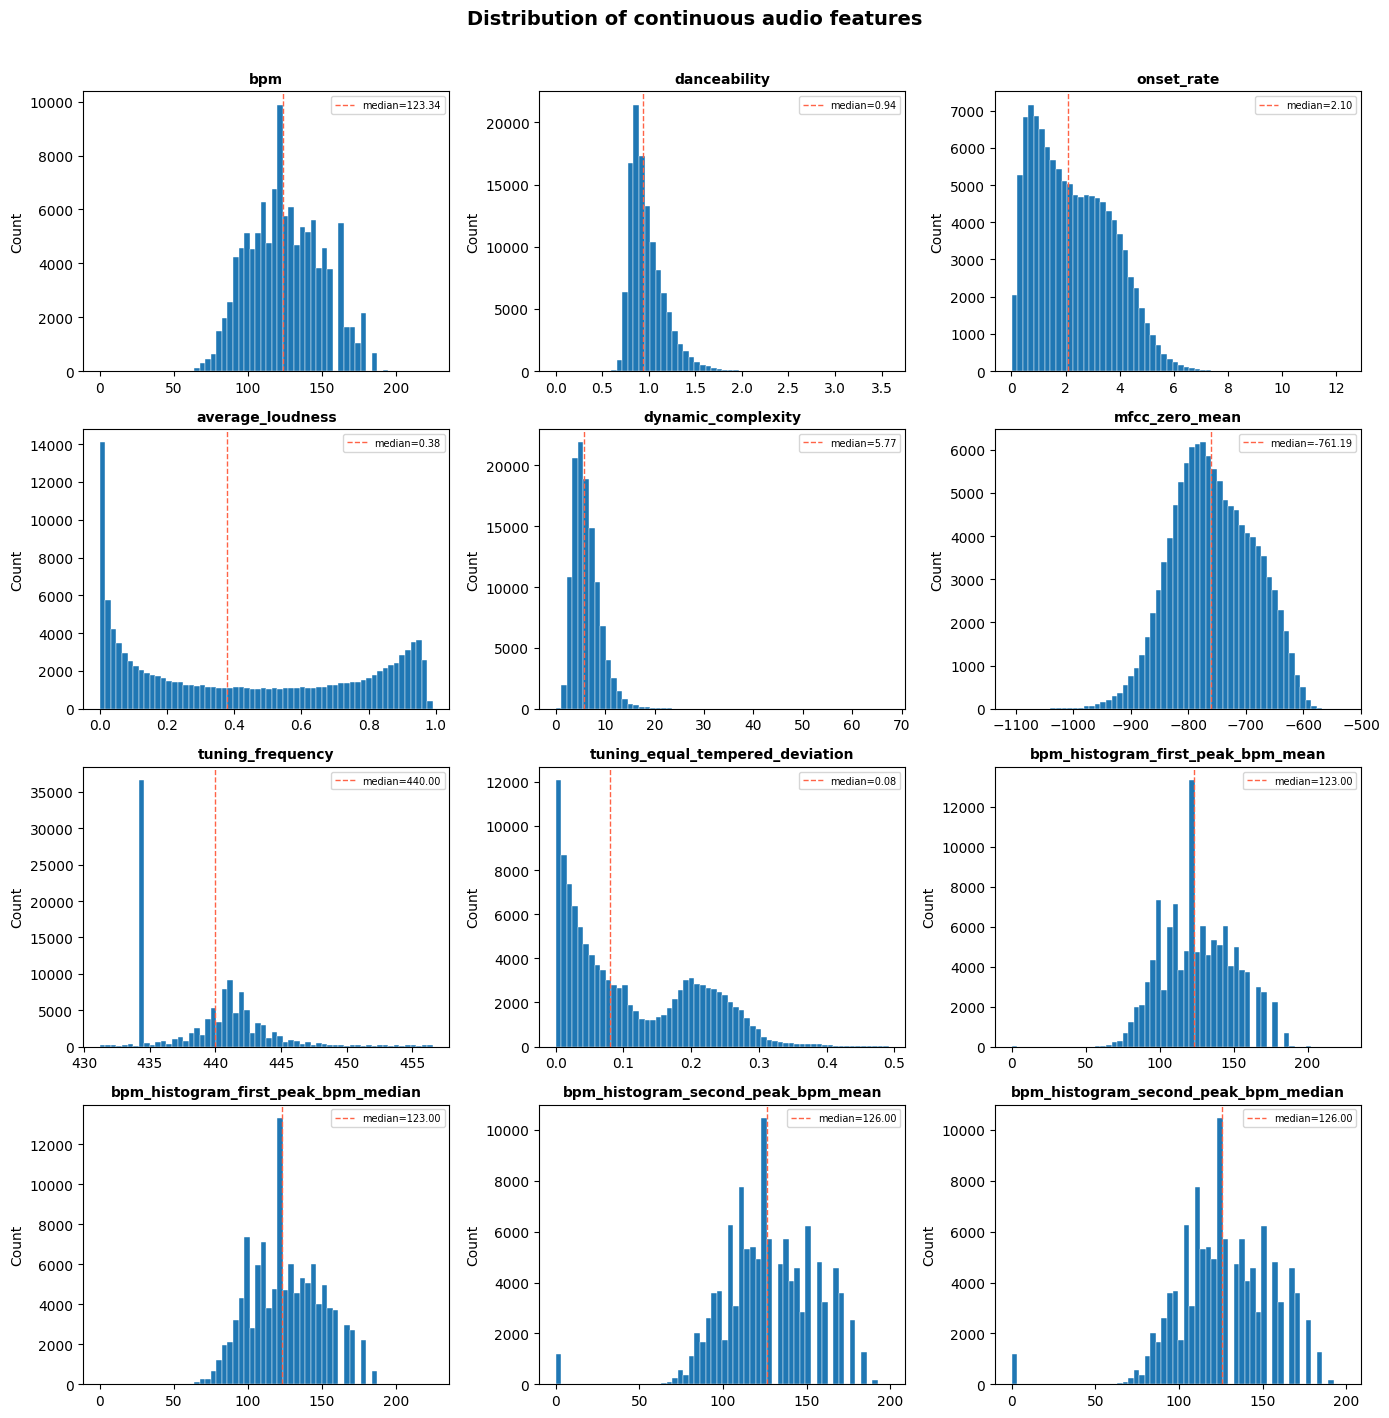

In [ ]:
n_cols = 3
n_rows = (len(CONTINUOUS_FEATURES) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(CONTINUOUS_FEATURES):
    ax = axes[i]
    data = df[col].dropna()

    ax.hist(data, bins=60, edgecolor="white", linewidth=0.3)
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_ylabel("Count")

    med = data.median()
    ax.axvline(med, color="tomato", linestyle="--", linewidth=1, label=f"median={med:.2f}")
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of continuous audio features", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("02_feature_distributions.png", bbox_inches="tight")
plt.show()

Some of the features seem relatively normally distributed, but there are also some things worth noting that may require further investigation:
- `tuning_frequency` has an extreme spike at 434 Hz, meaning variation for this feature will be very low. It may generate noise and not contribute meaningfully to the model. 
- `average_loudness` shows a U-shaped curve with high counts at both 0 and ~1.0. This could suggest two distinct data populations (e.g. tracks with different loudness normalization schemes or a mix of raw vs. pre-processed audio)
- `tuning_equal_tempered_deviation` also appears to be bimodal, potentially reflecting two tuning conventions
- `danceability` and `onset_rate` are right-skewed
- `bpm_histogram_second_peak_bpm_mean` and `bpm_histogram_second_peak_bpm_median` seem to have outliers at around 0
- `bpm_histogram_second_peak_bpm_mean`/`bpm_histogram_second_peak_bpm_median` and `bpm_histogram_first_peak_bpm_mean`/`bpm_histogram_first_peak_bpm_median` have nearly identical distributions (extremely high correlation), which could inflate feature dimensionality

## Visual 3: Feature correlation

Next, we check pairwise correlations between continuous features to help identify redundant features and potential multicollinearity issues.


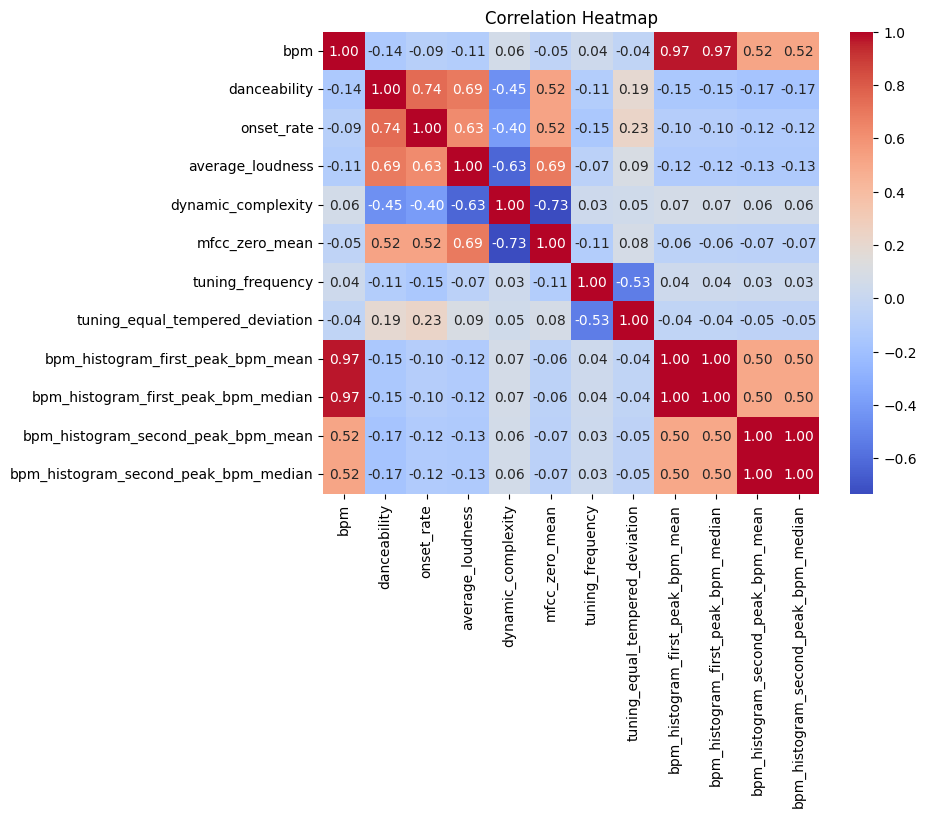

In [11]:
corr = df[CONTINUOUS_FEATURES].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")

plt.savefig("03_correlation_heatmap.png", bbox_inches="tight")
plt.show()


The heatmap shows that BPM histogram columns (first/second peak mean/median) are highly correlated with each other (r = 1) and with `bpm` (r = 0.97). Not only that, `mfcc_zero_mean` and `dynamic_complexity` show a high correlation (r = -073). To address multicollinearity, we plan to test multiple thresholds and analyze which performs best.

## Visual 4: Outliers

We use box plots and IQR-based counts to quantify outliers per feature.


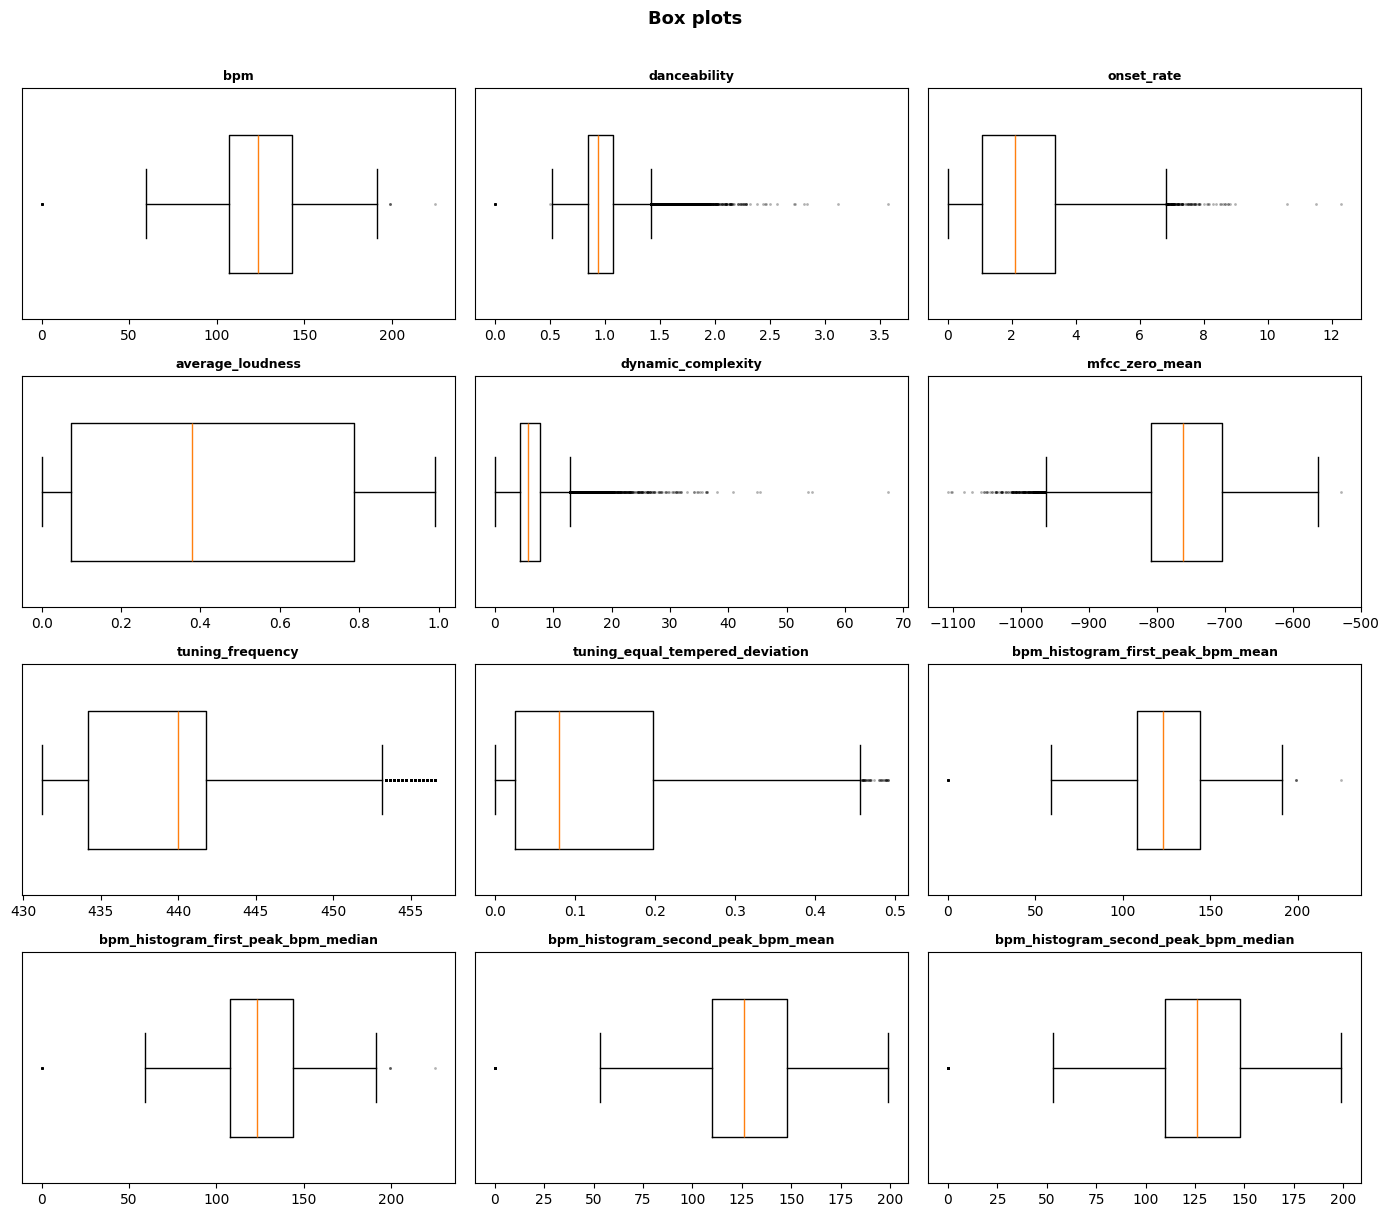

                             feature       q1       q3  lower_fence  upper_fence  n_outliers  pct_outliers
                                 bpm  107.247  143.152       53.389      197.009          19          0.02
                        danceability    0.848    1.077        0.504        1.421        3760          3.24
                          onset_rate    1.058    3.363       -2.399        6.820         130          0.11
                    average_loudness    0.074    0.786       -0.993        1.853           0          0.00
                  dynamic_complexity    4.275    7.700       -0.862       12.838        2785          2.40
                      mfcc_zero_mean -807.981 -704.254     -963.572     -548.664         261          0.22
                    tuning_frequency  434.193  441.783      422.809      453.167        1181          1.02
     tuning_equal_tempered_deviation    0.026    0.198       -0.233        0.457          40          0.03
   bpm_histogram_first_peak_bpm_mean 

In [13]:
n_cols = 3
n_rows = (len(CONTINUOUS_FEATURES) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows))
axes = axes.flatten()

outlier_summary = []

for i, col in enumerate(CONTINUOUS_FEATURES):
    ax = axes[i]
    data = df[col].dropna()

    ax.boxplot(data, vert=False, widths=0.6,
               flierprops=dict(marker=".", markersize=2, alpha=0.3))
    ax.set_title(col, fontsize=9, fontweight="bold")
    ax.set_yticks([])

    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((data < lower) | (data > upper)).sum()

    outlier_summary.append({
        "feature": col,
        "q1": round(q1, 3),
        "q3": round(q3, 3),
        "lower_fence": round(lower, 3),
        "upper_fence": round(upper, 3),
        "n_outliers": n_outliers,
        "pct_outliers": round(n_outliers / len(data) * 100, 2),
    })

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Box plots", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("04_outlier_boxplots.png", bbox_inches="tight")
plt.show()

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))


Outliers seem most common for the `danceability` feature, with 3,760 observations falling 1.5 * IQR below Q1 or above 1.5 * IQR Q3. To address outliers, we plan to experiment with various thresholds and see what performs best -- tree-based models (Random Forest, XGBoost) will be robust to outliers, but for logistic regression, we will likely want to implement robust scaling.
